# Introduction

In [1]:
import numpy as np
import csv
import pandas as pd
import math
import matplotlib.pyplot as plt
from tqdm import tqdm

# Problem I

## Functions used

In [2]:
# import csv files
# Import the training data
flight_data_train = np.loadtxt('flight_data_train.csv', delimiter = ',')
# Import the testing data
flight_data_test = np.loadtxt('flight_data_test.csv', delimiter = ',')

In [3]:
# Create function(s) to make Phi matrix
def make_Phi(data,m):
    Phi = []
    for row in data:
        # construct row features
        Phi.append(make_Phi_row(row[:-1],m)) 
    return np.transpose(Phi)

def make_Phi_row(x,m):
    Phi_row = []
    for j in x:
        for i in range(m):
            Phi_row.append(j**(i + 1)) 
    Phi_row.append(1)
    return Phi_row

'''
Column-wise Matrix Normalization
@input = A numeric matrix
@output = That matrix, with the values normalized column-wise
'''
def normalizer(matrix):
    for i in range(len(matrix[0])):
        col_max = np.max(matrix[:,i]);
        col_min = np.min(matrix[:,i]);
        matrix[:,i] = (matrix[:,i] - col_min) / (col_max - col_min)
    return matrix

'''
Root Mean Square Function
@inputs = data, experimental result
@inputs = ref, reference result
@output = the root mean square error of those two data
'''
def RMSE(data,ref):
    MSE = np.square(np.subtract(data,ref)).mean() 
    return math.sqrt(MSE)

'''
Weighted Training Output - with lnlambda 
@inputs = m, The number of features
@inputs = data, training data to use
@inputs = lnlambda, the hyperparameter used
@output = The output from training data inputs and weights
'''
def lambda_output(m, data, lnlambda):
    Phi_ = np.transpose(make_Phi(data, m))
    Phi_prod_ = np.matmul(np.transpose(Phi_),Phi_)
    I_ = np.identity(len(Phi_[0]))
    training_output_ = data[:,-1]

    firstterm = np.linalg.pinv(np.exp(lnlambda)*I_+Phi_prod_)      # lambda = exp(i)
    weight_ = np.matmul(firstterm,np.matmul(np.transpose(Phi_),training_output_))
    
    y_train_ = np.matmul(Phi_,weight_)
    return y_train_

'''
Cross Validation with n-folds
@inputs = cleanData, The data to use for the folds
@inputs = nFolds, number of folds
@inputs = m, number of features
@inputs = hyperparam, the hyperparameter used
@output = Average error from the cross validation technique
'''
def crossValidation(cleanData,nFolds,m,hyperparam):

    foldSize = int(len(cleanData)/nFolds)
    
    foldErrors = []
    
    for i in range(nFolds):
        data = cleanData
        fold = data[i*foldSize:i*foldSize+foldSize][:]
        for j in range(foldSize):
            data = np.delete(data,i*foldSize,0)
        exp_output = lambda_output(m,fold,hyperparam)
        training_output_ = data[:,-1]
        Phi_test_ = make_Phi(fold, m)
        Phi_train_ = make_Phi(data, m)

        weighting = np.matmul(np.linalg.pinv(np.transpose(Phi_train_)),training_output_)
        output_test = np.matmul(np.transpose(Phi_test_),weighting)
        foldErrors.append(np.abs(exp_output - output_test))
    return np.average(foldErrors)
'''
Root Mean Square Function
@inputs = data, experimental result
@inputs = ref, reference result
@output = the root mean square error of those two data
'''
def RMSE(data,ref):
    MSE = np.square(np.subtract(data,ref)).mean() 
    return math.sqrt(MSE)


## Problem I.1
Linear Regression

100%|██████████| 16/16 [00:00<00:00, 16.51it/s]


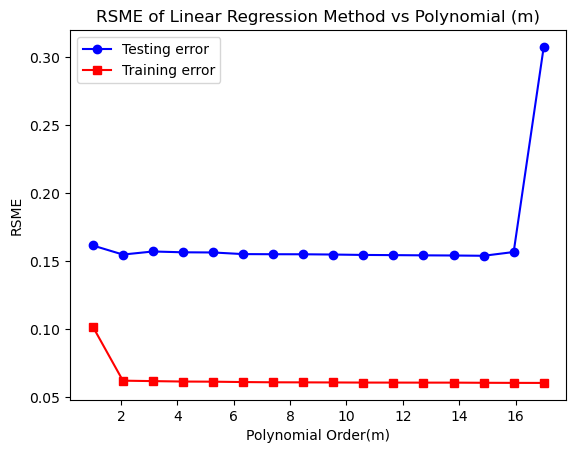

In [4]:
# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize =   (flight_data_train - minTrain)/(maxTrain - minTrain)

minTest = np.min(flight_data_test,axis = 0)
maxTest = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest)/(maxTest - minTest)

trainingError = []
testingError = []

poly_range = 16
for m in tqdm(range(poly_range)):
    
    # Build matrix Phi
    Phi_train = np.transpose(make_Phi(train_normalize,m))
    # Test accuracy against 2nd data set
    Phi_test = np.transpose(make_Phi(test_normalize,m))
    m += 1
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    ## Compute Moore-Penrose Psuedoinverse (MPP) of Phi matrix
    # Perform Singular Value Decomposition
    # U_phi, s_phi, V_phi = np.linalg.svd(Phi_train)
    # Sigma_phi = np.diag(s_phi)
    # Phi_train_MPP = np.dot(U_phi.T , np.dot( np.linalg.inv(Sigma_phi) , V_phi.T))
    
    # Calculate weights with two different methods (SVD MPP and built in MPP)
    weights = np.matmul(np.linalg.pinv(Phi_train),tTrain);
    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest = np.matmul(Phi_test,weights) 

    # Calculate training and test error
    trainingError.append(np.sqrt(np.square(yTrain-tTrain).mean() ) ) 
    testingError.append(np.sqrt( np.square(yTest -tTest ).mean() ) )
    
# Plot results
plt.figure()
plt.plot(np.linspace(1,m+1,m),testingError,  'bo-', label = 'Testing error')
plt.plot(np.linspace(1,m+1,m),trainingError, 'rs-',label = 'Training error')
# plt.ylim([0,0.16])
plt.xlabel("Polynomial Order(m)")
plt.ylabel("RSME")
plt.legend()
plt.title('RSME of Linear Regression Method vs Polynomial (m)')
plt.show()

## Problem 1.2
Ridge Regression

### Generate Data

In [5]:
from numpy.linalg import inv

# Normalize data
minTrain = np.min(flight_data_train,axis = 0)
maxTrain = np.max(flight_data_train,axis = 0)
train_normalize = (flight_data_train - minTrain) / (maxTrain - minTrain)

minTest        = np.min(flight_data_test,axis = 0)
maxTest        = np.max(flight_data_test,axis = 0)
test_normalize = (flight_data_test - minTest) / (maxTest - minTest)

trainingErrorRidge = []
testingErrorRidge = []

# Build lambda values:
num_vals = (len(train_normalize[0]) - 1) ** 2  + 1

ln_lambda_min = -30
ln_lambda_max =  20

ln_lambda_vals = np.linspace(ln_lambda_min,ln_lambda_max,num_vals)
lambda_vals = np.exp(ln_lambda_vals)


for lambda_val in tqdm(lambda_vals):
    
    # Build matrix Phi
    Phi_train = np.transpose(make_Phi(train_normalize,m))
    # Test accuracy 
    Phi_test = np.transpose(make_Phi(test_normalize,m))
    
    # Remove the inputs from the data
    tTrain = train_normalize[:,-1]
    tTest  = test_normalize[:,-1]
    
    # Calculate weights
    lambda_identity = lambda_val * np.identity(np.size(Phi_train[0]))
    weights = lambda_identity + np.matmul(np.transpose(Phi_train),Phi_train)
    weights = np.linalg.pinv(weights)
    weights = np.matmul(np.matmul(weights,np.transpose(Phi_train)),tTrain);

    
    # Check the outputs
    yTrain = np.matmul(Phi_train,weights)
    yTest =  np.matmul(Phi_test, weights) 

    # Calculate training and test error
    trainingErrorRidge.append( np.sqrt(np.square(yTrain-tTrain).mean() ) )
    testingErrorRidge.append(  np.sqrt(np.square(yTest -tTest).mean() ) )

100%|██████████| 37/37 [00:02<00:00, 13.28it/s]


### Plot Results

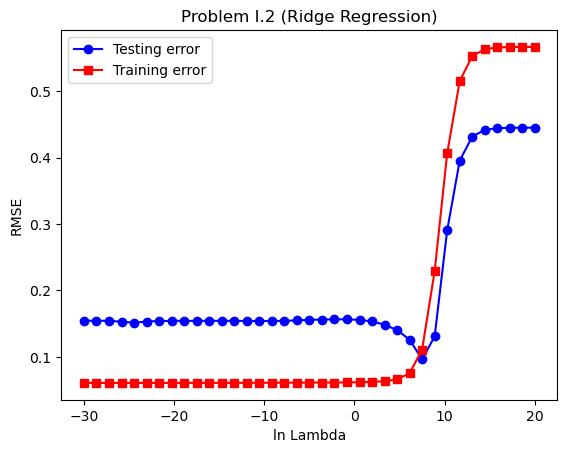

In [6]:
# Plot results
plt.plot(ln_lambda_vals,testingErrorRidge, 'bo-',label = 'Testing error')
plt.plot(ln_lambda_vals,trainingErrorRidge, 'rs-',label = 'Training error')
plt.xlabel("ln Lambda")
plt.ylabel("RMSE")
plt.title("Problem I.2 (Ridge Regression)")
plt.legend()
plt.show()

## Problem I.3
Lasso Regression

100%|██████████| 37/37 [00:55<00:00,  1.51s/it]


The lambda with the lowest 10-fold cross validation error is [0.43459821]
The lambda with the lowest AIC is [112.41779262]
The lambda with the lowest BIC is [450.83936961]


<Figure size 640x480 with 0 Axes>

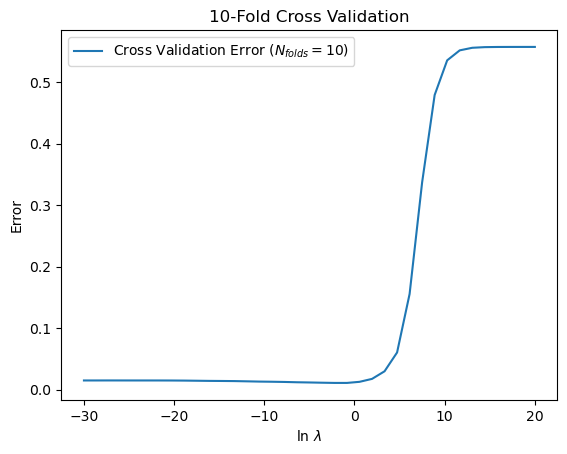

<Figure size 640x480 with 0 Axes>

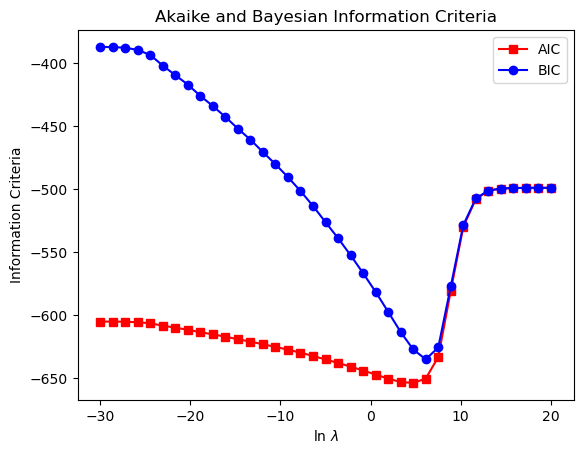

In [14]:
"""
@Title:         Machine Learning Homework 2, Problem I Part 3
@Date:          Feruary 23, 2024
@author:        Jacob Sichlau
@Collaborator:  Michael Williams
@Collaborator:  Adim Seeler
"""

training_data = np.loadtxt("flight_data_train.csv",delimiter=",")
test_data = np.loadtxt("flight_data_test.csv",delimiter=",")


training_data = normalizer(training_data)
test_data = normalizer(test_data)

training_output = training_data[:,-1]
test_output = test_data[:,-1]

cross_errors = []
AIC = []
BIC = []
shuffled = training_data
np.random.shuffle(shuffled)
N = len(Phi_train[0])
Phi_prod = np.matmul(Phi_train.T,Phi_train)
I = np.identity(len(Phi_train[0]))



E_d = []
weights_2 = []
for i in ln_lambda_vals:
    firstterm = np.linalg.pinv(np.exp(i)*I+Phi_prod)        # lambda = exp(i)
    temp = np.matmul(firstterm,np.matmul(np.transpose(Phi_train),training_output))
    weights_2.append(temp)
    
    y_r_test = np.matmul(Phi_test,temp)
    y_r_train = np.matmul(Phi_train,temp)
    
    # RMSE_r_test.append(RMSE(y_r_test,test_output))
    # RMSE_r_train.append(RMSE(y_r_train,training_output))

    E_d.append(RMSE(y_r_train,training_output))            # for part 3


count = 0;
for i in tqdm(ln_lambda_vals):
    
    cross_errors.append(crossValidation(shuffled, 10, 6, i))
    
    temp = np.linalg.pinv(Phi_prod + np.exp(i)*I)       # lambda = exp(i)
    pre_gamma = np.matmul(temp, Phi_prod)
    gamma = np.trace(pre_gamma)
    
    AIC.append(N*np.log(E_d[count]/N)+gamma)
    BIC.append(N*np.log(E_d[count]/N)+gamma*np.log(N))
    count += 1

fig_3 = plt.figure()
fig_3, aaax = plt.subplots()
aaax.plot(ln_lambda_vals, cross_errors, 'o-', label='Cross Validation Error ($N_{folds} = 10$)')
aaax.set_xlabel('ln $\lambda$')
aaax.set_ylabel('Error')
aaax.set_title("10-Fold Cross Validation")
aaax.legend()

fig_4 = plt.figure()
fig_4, ax = plt.subplots()
ax.plot(ln_lambda_vals, AIC, 'rs-', label='AIC')
ax.plot(ln_lambda_vals, BIC, 'bo-', label='BIC')
ax.set_xlabel('ln $\lambda$')
ax.set_ylabel('Information Criteria')
ax.set_title("Akaike and Bayesian Information Criteria")
ax.legend()

cross_min_lambda = np.exp(ln_lambda_vals[np.where(cross_errors == min(cross_errors))])
print(f'The lambda with the lowest 10-fold cross validation error is {cross_min_lambda}')

AIC_min_lambda = np.exp(ln_lambda_vals[np.where(AIC == min(AIC))])
print(f'The lambda with the lowest AIC is {AIC_min_lambda}')

BIC_min_lambda = np.exp(ln_lambda_vals[np.where(BIC == min(BIC))])
print(f'The lambda with the lowest BIC is {BIC_min_lambda}')

# Problem II

# Problem IV

## Part 2

In [8]:
# import csv files
# Import the training data
steel_data_train = np.loadtxt('steel_composition_train.csv', delimiter = ',')

In [9]:

def  colonelPartA (x,train):
    kern = []
    for row in train:
        kern.append((np.dot(x,row)+1) ** 2)
    return kern

def  kernalPartB (x,train):
    kern = []
    for row in train:
        kern.append((np.dot(x,row)+1) ** 3)
    return kern

def  kernalPartIII (x,train):
    kern = []
    for row in train:
        kern.append((np.dot(x,row)+1) ** 4)
    return kern

def  kernelPartD (x,train):
    kern = []
    Sigma  = 1
    for row in train:
        kern.append(np.exp(-np.linalg.norm(x-row)**2)/2*Sigma**2)
    return kern

minTrain = np.min(steel_data_train,axis = 0)
maxTrain = np.max(steel_data_train,axis = 0)
train_normalize = (steel_data_train - minTrain)/(maxTrain - minTrain)

# Constants
Lambda = 1

tTrain = train_normalize[:,:-1] # Data inputs
yTrain = train_normalize[:, -1] # Data outputs

trainingErrorA = []
trainingErrorB = []
trainingErrorD = []
trainingErrorC = []

# Make Phi matrices
Phi_2 =  np.transpose(make_Phi(train_normalize, 2))
Phi_3 = np.transpose(make_Phi(train_normalize, 3))

# Initialize K 
K2_gram = np.matmul(Phi_2,np.transpose(Phi_2))
# K3_gram = makePhi(train_normalize, 3)
# K4_gram = 
# Kgauss = 

for row in tqdm(tTrain):
    yA = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * colonelPartA(row,tTrain))
    yB = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * kernalPartB(row,tTrain))
    yC = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * kernalPartIII(row,tTrain))
    yD = np.transpose(yTrain) * (Lambda * np.eye(len(train_normalize)) * kernelPartD(row,tTrain))
    trainingErrorA.append((yA-yTrain)**2)
    trainingErrorB.append((yB-yTrain)**2)
    trainingErrorD.append((yD-yTrain)**2)
    trainingErrorC.append((yC-yTrain)**2)

100%|██████████| 618/618 [00:24<00:00, 24.73it/s]


In [10]:
# trainingErrorA=( np.sqrt(np.array(trainingErrorA).mean() ) )
# trainingErrorB=( np.sqrt(np.array(trainingErrorB).mean() ) )
# trainingErrorD=( np.sqrt(np.array(trainingErrorD).mean() ) )
# trainingErrorC=( np.sqrt(np.array(trainingErrorC).mean() ) )
# print(trainingErrorA)
# print(trainingErrorB)
# print(trainingErrorD)
# print(trainingErrorC)